In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm

In [2]:
RAW_ROOT = "../data/raw/hyper-kvasir-labeled-image"
OUT_ROOT = "../data/processed/hyper_kvasir_clean"

LOWER_GI_IN = os.path.join(RAW_ROOT, "lower-gi-tract")
UPPER_GI_IN = os.path.join(RAW_ROOT, "upper-gi-tract")

LOWER_GI_OUT = os.path.join(OUT_ROOT, "lower-gi-tract")
UPPER_GI_OUT = os.path.join(OUT_ROOT, "upper-gi-tract")

os.makedirs(LOWER_GI_OUT, exist_ok=True)
os.makedirs(UPPER_GI_OUT, exist_ok=True)

In [3]:
def mask_ui_artifact(img):
    """
    Masks blue/green UI overlays from endoscopy images.
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Blue-green UI overlay range (tuned for Hyper-Kvasir)
    lower = np.array([35, 40, 40])
    upper = np.array([100, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    # Morphological cleanup
    kernel = np.ones((7,7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Apply mask (black out artifact)
    img_clean = img.copy()
    img_clean[mask > 0] = 0

    return img_clean, mask

In [5]:
def process_folder(input_dir, output_dir):
    for root, _, files in os.walk(input_dir):
        rel_path = os.path.relpath(root, input_dir)
        save_dir = os.path.join(output_dir, rel_path)
        os.makedirs(save_dir, exist_ok=True)

        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                in_path = os.path.join(root, f)
                out_path = os.path.join(save_dir, f)

                img = cv2.imread(in_path)
                if img is None:
                    continue

                clean_img, _ = mask_ui_artifact(img)
                cv2.imwrite(out_path, clean_img)
process_folder(LOWER_GI_IN, LOWER_GI_OUT)
process_folder(UPPER_GI_IN, UPPER_GI_OUT)

In [6]:
import matplotlib.pyplot as plt

def compare_original_vs_clean(img_path):
    img = cv2.imread(img_path)
    clean, mask = mask_ui_artifact(img)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    clean = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Artifact Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(clean)
    plt.title("Cleaned Image")
    plt.axis("off")

    plt.show()

Sample image: ../data/raw/hyper-kvasir-labeled-image/lower-gi-tract/quality-of-mucosal-views/impacted-stool/4bf58f1c-8233-41fc-9614-344e6d0fc351.jpg


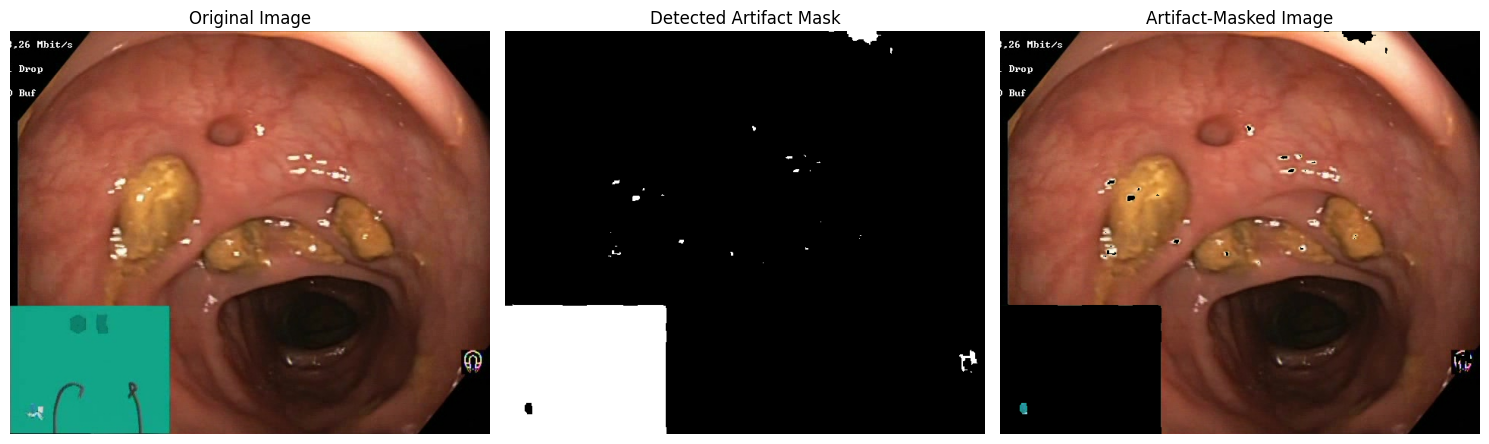

In [7]:
# ================================
# VISUAL VERIFICATION (IMPORTANT)
# ================================

import cv2
import matplotlib.pyplot as plt

# Pick ONE sample image manually
sample_img_path = None
for root, _, files in os.walk(LOWER_GI_IN):
    for f in files:
        if f.lower().endswith((".jpg", ".png", ".jpeg")):
            sample_img_path = os.path.join(root, f)
            break
    if sample_img_path:
        break

print("Sample image:", sample_img_path)

# Load image
img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply artifact masking
clean_img, mask = mask_ui_artifact(img)

# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Detected Artifact Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(clean_img)
plt.title("Artifact-Masked Image")
plt.axis("off")

plt.tight_layout()
plt.show()